Q2: Unsupervised Learning

Task 1: Data Preparation

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv(r"C:\Users\sriva\Downloads\data\q2_customers.csv")
# Display first five rows
df.head()

# Initialize scaler
scaler = StandardScaler()

# Scale all features
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame (optional, for readability)
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

# Check result
df_scaled.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


K-Means clustering is a distance-based algorithm that relies on Euclidean distance to group data points. If the features in the dataset are on different scales (for example, age might range from 18–60 while annual spend could be in thousands), the algorithm will give more importance to features with larger values.

This leads to biased clustering, where variables with higher magnitudes dominate the distance calculations, even if they are not the most important.

Standardizing the data using StandardScaler ensures that:

- All features have a mean of 0 and standard deviation of 1
- Each feature contributes equally to distance calculations
- The clustering results become more accurate and meaningful

Without scaling, K-Means may produce misleading clusters due to unequal feature influence.

Task 2: Elbow Method (Choosing K)

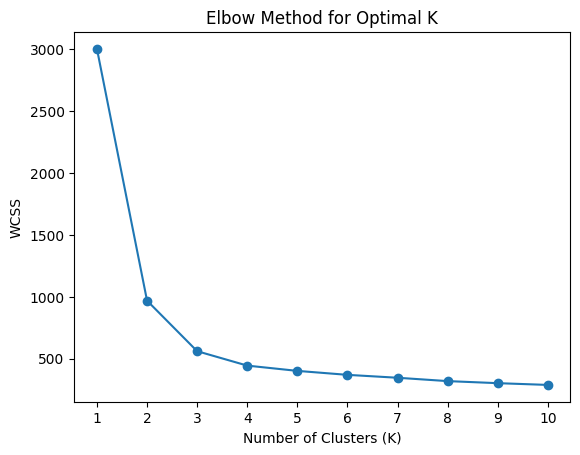

In [ ]:

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

# Try K values from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

# Plot the elbow curve
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.show()
# From the elbow plot, we can choose K=3 as the optimal number of clusters


The Elbow Method is used to determine the optimal number of clusters by plotting the Within-Cluster Sum of Squares (WCSS) against different values of K.

WCSS measures how compact the clusters are (lower is better).
As K increases, WCSS decreases because clusters become smaller and tighter.
However, after a certain point, the rate of decrease slows down significantly.

This point of sharp change in the curve is called the “elbow point”.
Here, the curve shows a clear bend at K = 3, it indicates that:

Adding more clusters beyond 3 does not significantly improve clustering.
Therefore, K = 3 is the optimal number of clusters.

Task 3: K-Means Clustering

In [ ]:
# Choose optimal K based on elbow plot
optimal_k = 3

# Fit K-Means with K=3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Add 'cluster' label to original dataframe
df['cluster'] = clusters

# View first few rows
df.head()




,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [6]:
# Get centroids in scaled form
centroids_scaled = kmeans.cluster_centers_

# Convert back to original scale
centroids = scaler.inverse_transform(centroids_scaled)

# Create DataFrame for readability
centroids_df = pd.DataFrame(centroids, columns=df.columns[:-1])  # exclude 'cluster'

centroids_df

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster Interpretation

Cluster 0: High-Value Loyal Customers
This group consists of customers with high annual spend, frequent visits, and larger basket sizes. They also tend to purchase across multiple categories. These are premium customers who contribute significantly to revenue and should be targeted with loyalty programs and exclusive offers.

Cluster 1: Occasional Moderate Spenders
Customers in this cluster have moderate spending and visit frequency. Their engagement is average, and they may not consistently purchase across many categories. Marketing efforts like personalized recommendations or discounts could help increase their engagement.

Cluster 2: Low-Engagement Customers
This cluster includes customers with low spending, infrequent visits, and small basket sizes. They also tend to have a higher number of days since their last visit. These customers are at risk of churn and may require re-engagement strategies such as promotions or reminders.

Task 4: Dimensionality Reduction with PCA

In [9]:

from sklearn.decomposition import PCA

# Initialize PCA with 2 components
pca = PCA(n_components=2, random_state=42)

# Fit and transform scaled data
pca_data = pca.fit_transform(df_scaled)

# Create DataFrame for PCA results
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

df_pca.head()



,PC1,PC2
0,-0.333082,0.109379
1,-2.255362,0.048458
2,-0.092905,-0.679257
3,-2.017598,-0.308845
4,-2.917762,0.529368


In [10]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
for i, var in enumerate(explained_variance, start=1):
    print(f"PC{i}: {var:.4f}")

Explained Variance Ratio:
PC1: 0.8356
PC2: 0.0557


In [11]:
# PCA components (loadings)
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],  # exclude 'cluster'
    index=['PC1', 'PC2']
)

loadings


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


Interpretation of Principal Components

PC1 (Principal Component 1):
PC1 captures the overall customer value and engagement level. Features such as annual_spend, visits_per_month, and basket_size typically have strong positive loadings here. This means customers with high PC1 scores are high spenders, frequent visitors, and more engaged shoppers.

PC2 (Principal Component 2):
PC2 often represents recency and diversity of behavior. For example, days_since_last_visit may have a strong positive loading, while num_categories_purchased or visit frequency may load negatively. This component helps differentiate between recently active customers and those who haven’t visited in a while.

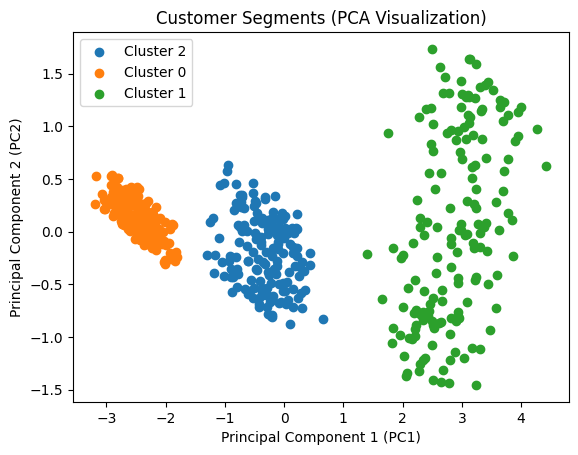

In [12]:
import matplotlib.pyplot as plt

# Combine PCA data with cluster labels
df_pca['cluster'] = df['cluster']

# Create scatter plot
plt.figure()
for cluster in df_pca['cluster'].unique():
    subset = df_pca[df_pca['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {cluster}')

# Labels and title
plt.title('Customer Segments (PCA Visualization)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend()

plt.show()